In [20]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from src.bare_param import get_bare_param_n

<h1> Generate set of bare param </h1>

In [21]:
omega_A = 10*pi
gamma_A = 5*pi

nb_pts = 1000
lbda_tab = np.linspace(0.1,500,nb_pts)
omega_ref_tab = [0,2*pi,4*pi,6*pi,8*pi,10*pi,12*pi,14*pi,16*pi,18*pi,20*pi]

omega_0_to_plot = []
gamma_0_to_plot = []

for w in omega_ref_tab:
    ir_cutoff_tab = w - lbda_tab
    uv_cutoff_tab = w + lbda_tab

    omega_0_tab = np.zeros(nb_pts)
    gamma_0_tab = np.zeros(nb_pts)

    for i in range(nb_pts):
        omega_0_tab[i], gamma_0_tab[i] = get_bare_param_n(omega_A, gamma_A, ir_cutoff_tab[i], uv_cutoff_tab[i])
    
    omega_0_to_plot.append(omega_0_tab)
    gamma_0_to_plot.append(gamma_0_tab)

/Users/romainpiron/Documents/NII_local/two_photon_renorm/src/bare_param.py:82: RuntimeWarning: invalid value encountered in log
  residual_diff = omega_A - w0_guess + Gamma /(2*pi) * np.log((uv - w0_guess) / (w0_guess - ir))


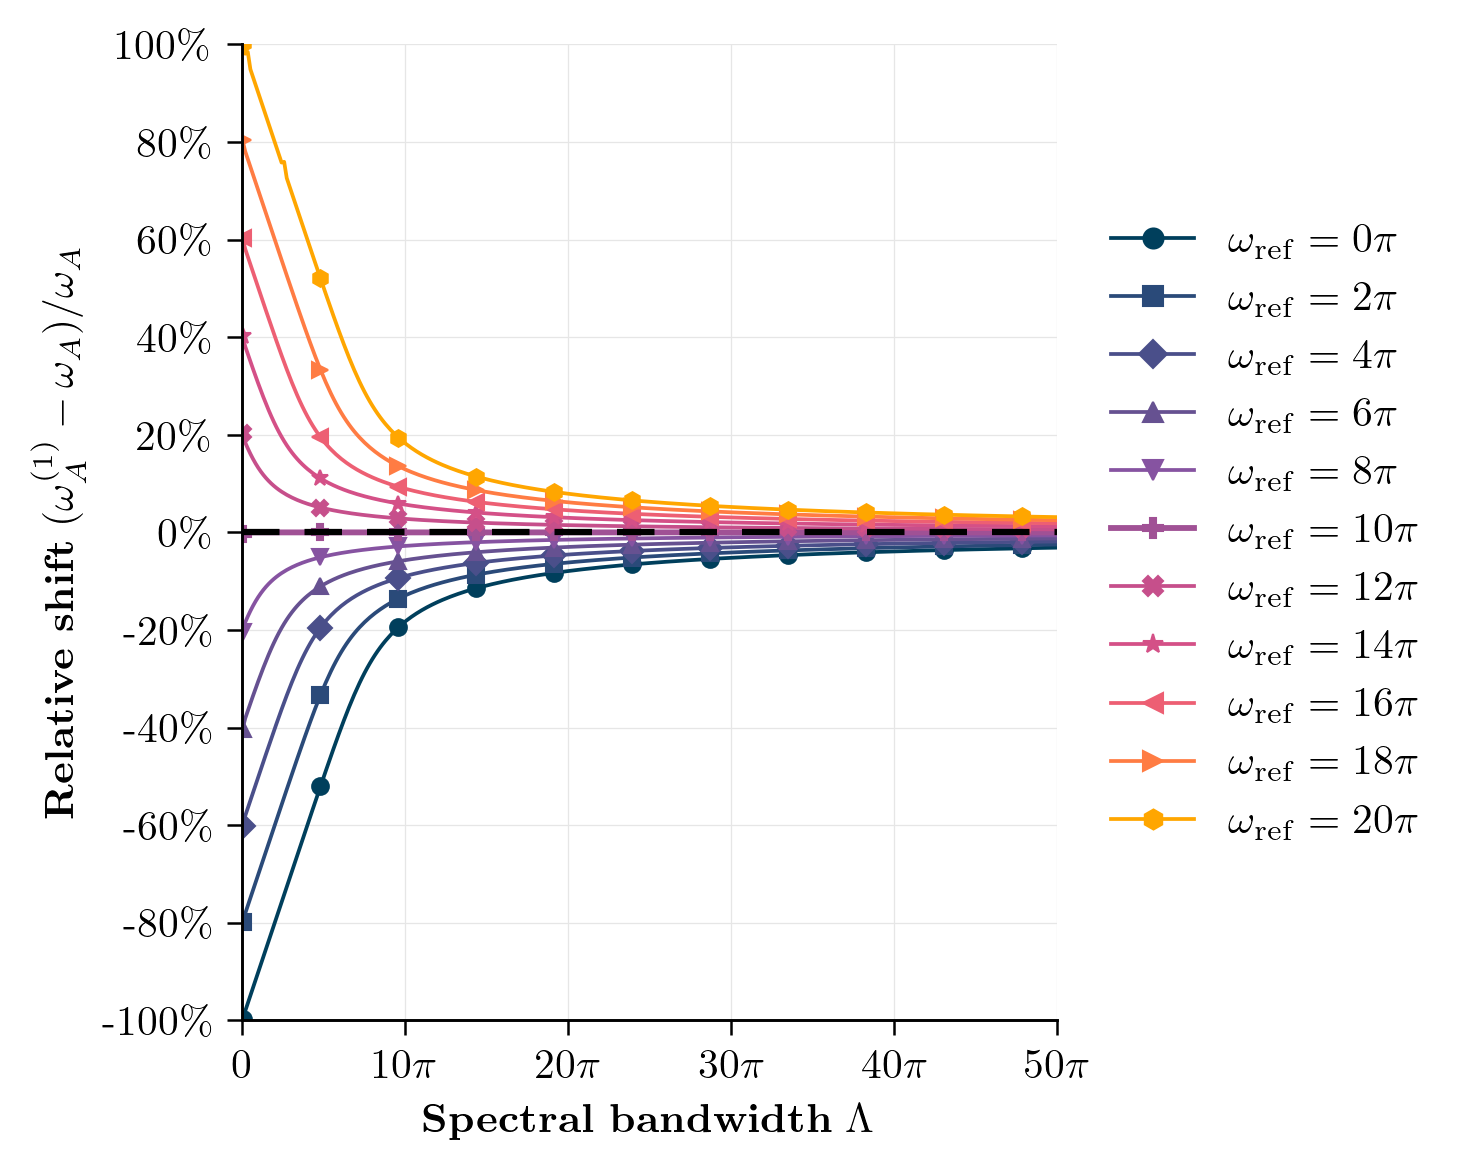

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# =========================
# palette + markers
# =========================

colors = [
"#003f5c",
"#2a4a79",
"#4a4f8a",
"#665191",
"#8653a1",
"#a05195",
"#c64f8b",
"#d45087",
"#ed5f73",
"#ff7c43",
"#ffa600"
]

markers = [
"o",
"s",
"D",
"^",
"v",
"P",
"X",
"*",
"<",
">",
"h"
]

# =========================
# figure
# =========================

fig, ax = plt.subplots(figsize=(5,4), dpi=300)

for i, w in enumerate(omega_ref_tab):

    rel_shift = (omega_0_to_plot[i] - omega_A) / omega_A
    
    lw = 1.4 if np.isclose(w, omega_A) else 0.9

    ax.plot(
        lbda_tab,
        rel_shift,
        label=rf'$\omega_{{\mathrm{{ref}}}}={w/np.pi:.0f}\pi$',
        color=colors[i],
        marker=markers[i],
        linewidth=lw,
        markersize=4,
        markeredgewidth=0.5,
        markevery=30
    )

# =========================
# x-axis
# =========================

ax.set_xlim([0, 50*np.pi])

ax.xaxis.set_major_locator(MultipleLocator(10*np.pi))

def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

# =========================
# y-axis
# =========================

ticks = np.linspace(-1,1,11)
labels = [f"{round(t*100)}\\%" for t in ticks]

ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.set_ylim(-1,1)

# =========================
# labels
# =========================

ax.set_xlabel(r'\textbf{Spectral bandwidth} $\Lambda$')
ax.set_ylabel(r'\textbf{Relative shift} $(\omega_A^{(1)}-\omega_A)/\omega_A$')

# =========================
# reference line
# =========================

ax.axhline(
    0,
    color='black',
    linewidth=1.5,
    linestyle=(0, (6, 4)),   # dash pattern : 6 on / 4 off
    zorder=5
)

# =========================
# legend
# =========================

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02,0.5),
    frameon=False,
    markerscale=1.2
)

# =========================
# style tweaks
# =========================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(color='0.9', linestyle='-', linewidth=0.3)

# =========================
# font size
# =========================

for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
plt.show()

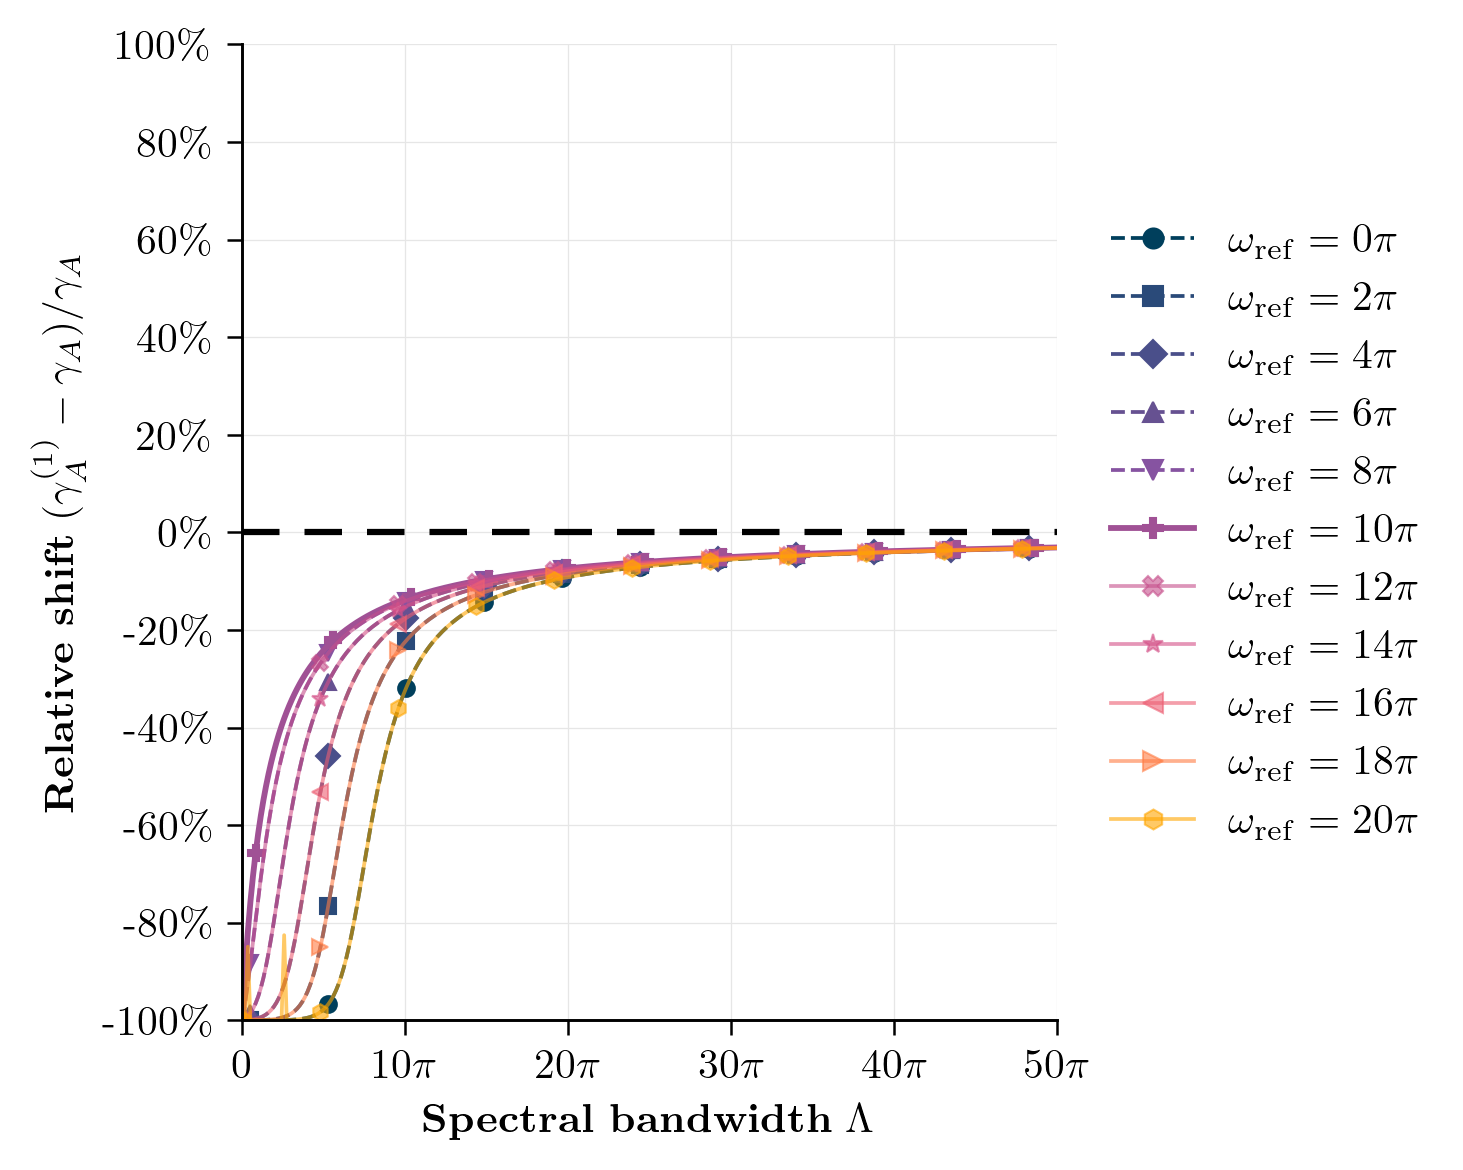

In [45]:
# =========================
# palette + markers (11)
# =========================
colors = [
"#003f5c",
"#2a4a79",
"#4a4f8a",
"#665191",
"#8653a1",
"#a05195",
"#c64f8b",
"#d45087",
"#ed5f73",
"#ff7c43",
"#ffa600"
]

markers = [
"o",
"s",
"D",
"^",
"v",
"P",
"X",
"*",
"<",
">",
"h"
]

# =========================
# figure
# =========================
fig, ax = plt.subplots(figsize=(5,4), dpi=300)

for i, w in enumerate(omega_ref_tab):

    rel_shift = (gamma_0_to_plot[i] - gamma_A)/gamma_A
    
    lw = 1.4 if np.isclose(w, omega_A) else 0.9
    
    if w in [0,2*pi, 4*pi, 6*pi, 8*pi]:
        offset = 3
        style='--'
        transparency = 1

    elif w == 10*pi:
        offset = 5
        style='-'
        transparency = 1
    else:
        offset = 0
        style ='-'
        transparency = 0.6

    ax.plot(
        lbda_tab,
        rel_shift,
        label=rf'$\omega_{{\mathrm{{ref}}}}={w/np.pi:.0f}\pi$',
        color=colors[i],
        marker=markers[i],
        linewidth=lw,
        linestyle=style,
        markersize=4,
        markeredgewidth=0.5,
        alpha=transparency,
        markevery=range(offset, len(lbda_tab), 30)  # shift des markers
    )

# =========================
# x-axis
# =========================
ax.set_xlim([0, 50*np.pi])
ax.xaxis.set_major_locator(MultipleLocator(10*np.pi))

def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

# =========================
# y-axis
# =========================
ticks = np.linspace(-1,1,11)
labels = [f"{round(t*100)}\\%" for t in ticks]
ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.set_ylim(-1,1)

# =========================
# labels
# =========================
ax.set_xlabel(r'\textbf{Spectral bandwidth} $\Lambda$')
ax.set_ylabel(r'\textbf{Relative shift} $(\gamma_A^{(1)}-\gamma_A)/\gamma_A$')

# =========================
# reference line
# =========================
ax.axhline(
    0,
    color='black',
    linewidth=1.5,
    linestyle=(0, (6,4)),
    zorder=5
)

# =========================
# legend
# =========================
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02,0.5),
    frameon=False,
    markerscale=1.2
)

# =========================
# style tweaks
# =========================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='0.9', linestyle='-', linewidth=0.3)

# =========================
# font size
# =========================
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)
for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
plt.show()

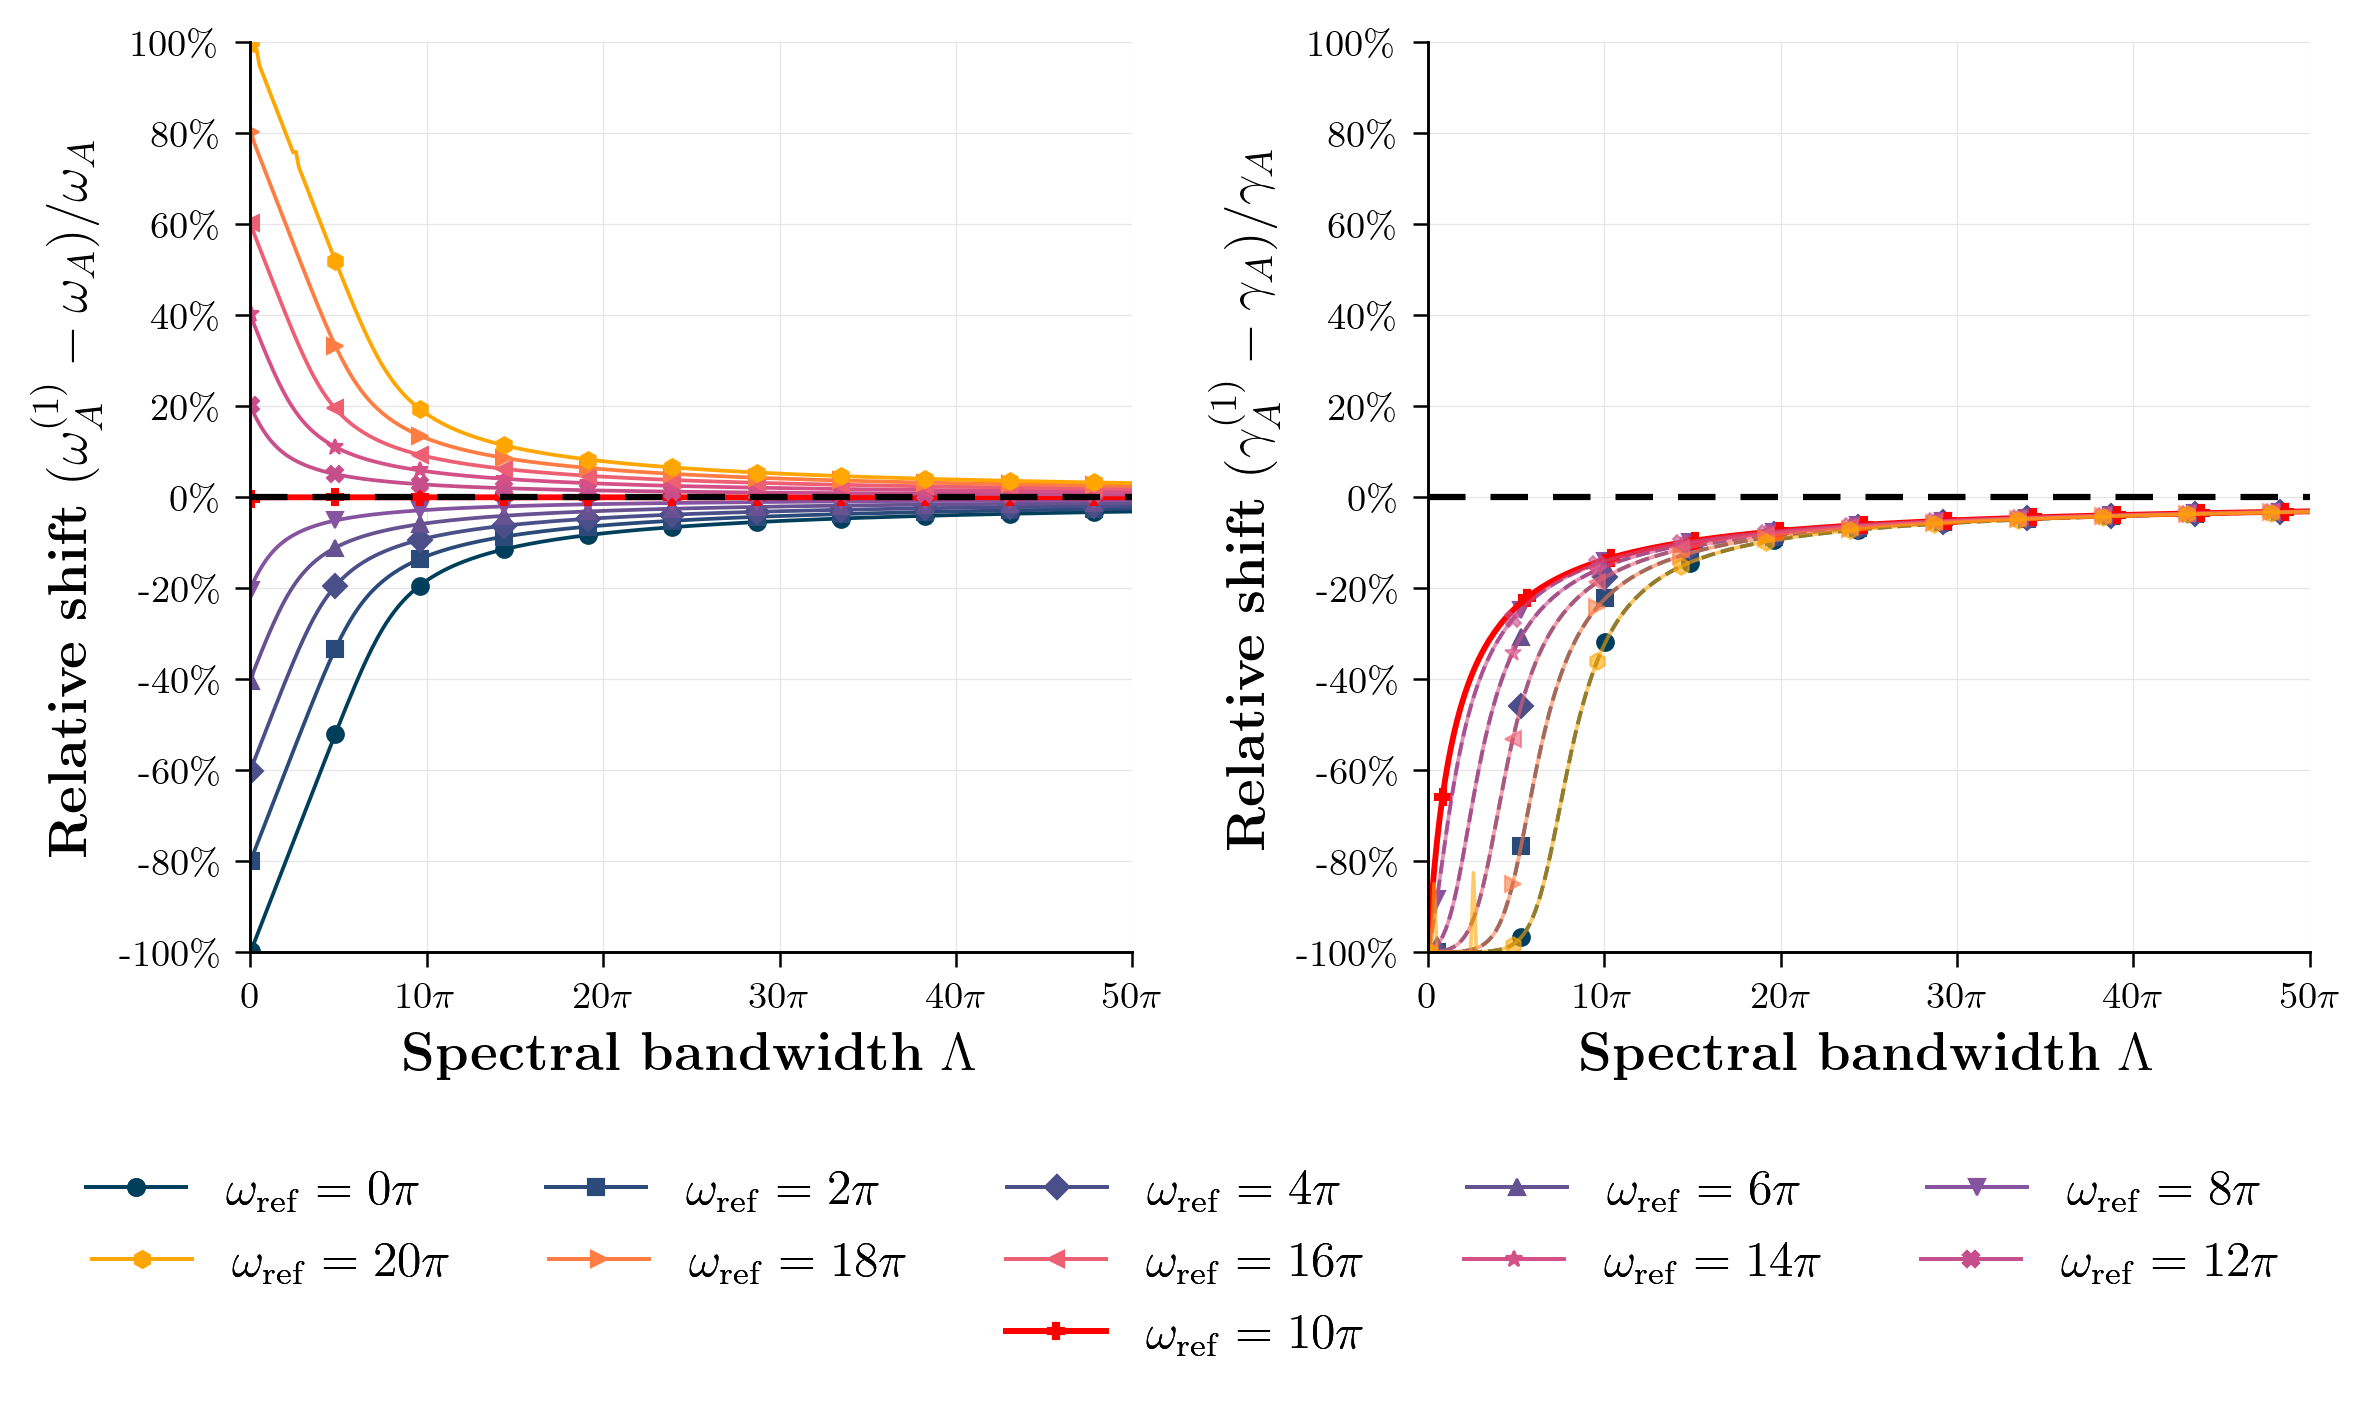

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# =========================
# palettes + markers
# =========================
colors = [
    "#003f5c","#2a4a79","#4a4f8a","#665191","#8653a1",
    "#ff0000","#c64f8b","#d45087","#ed5f73","#ff7c43","#ffa600"
] # rouge vif pour 10π
markers = ["o","s","D","^","v","P","X","*","<",">","h"]

# =========================
# fonction pour formatter x en pi
# =========================
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

# =========================
# figure avec 2 subplots
# =========================
fig, axs = plt.subplots(1,2, figsize=(8,4), dpi=300)
ax1, ax2 = axs

# =========================
# Plot 1 : Relative shift ω
# =========================
for i, w in enumerate(omega_ref_tab):
    rel_shift = (omega_0_to_plot[i] - omega_A) / omega_A
    lw = 1.4 if np.isclose(w, omega_A) else 0.9
    ax1.plot(
        lbda_tab,
        rel_shift,
        label=rf'$\omega_{{\mathrm{{ref}}}}={w/np.pi:.0f}\pi$',
        color=colors[i],
        marker=markers[i],
        linewidth=lw,
        markersize=4,
        markeredgewidth=0.5,
        markevery=30
    )

ax1.set_xlabel(r'\textbf{Spectral bandwidth} $\Lambda$')
ax1.set_ylabel(r'\textbf{Relative shift} $(\omega_A^{(1)}-\omega_A)/\omega_A$')
ax1.set_xlim([0,50*np.pi])
ax1.xaxis.set_major_locator(MultipleLocator(10*np.pi))
ax1.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax1.set_ylim(-1,1)
ticks = np.linspace(-1,1,11)
ax1.set_yticks(ticks)
ax1.set_yticklabels([f"{round(t*100)}\\%" for t in ticks])
ax1.axhline(0, color='black', linewidth=1.5, linestyle=(0,(6,4)))
ax1.grid(color='0.9', linestyle='-', linewidth=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# =========================
# Plot 2 : Relative shift γ
# =========================
for i, w in enumerate(omega_ref_tab):
    rel_shift = (gamma_0_to_plot[i] - gamma_A)/gamma_A
    lw = 1.4 if np.isclose(w, omega_A) else 0.9
    
    # style conditionnel pour markers et transparence
    if w in [0,2*np.pi,4*np.pi,6*np.pi,8*np.pi]:
        offset = 3
        style='--'
        alpha = 1
    elif np.isclose(w, 10*np.pi):
        offset = 5
        style='-'
        alpha = 1
    else:
        offset = 0
        style='-'
        alpha = 0.6
    
    ax2.plot(
        lbda_tab,
        rel_shift,
        label=rf'$\omega_{{\mathrm{{ref}}}}={w/np.pi:.0f}\pi$',
        color=colors[i],
        marker=markers[i],
        linewidth=lw,
        linestyle=style,
        markersize=4,
        markeredgewidth=0.5,
        alpha=alpha,
        markevery=range(offset, len(lbda_tab), 30)
    )

ax2.set_xlabel(r'\textbf{Spectral bandwidth} $\Lambda$')
ax2.set_ylabel(r'\textbf{Relative shift} $(\gamma_A^{(1)}-\gamma_A)/\gamma_A$')
ax2.set_xlim([0,50*np.pi])
ax2.xaxis.set_major_locator(MultipleLocator(10*np.pi))
ax2.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax2.set_ylim(-1,1)
ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{round(t*100)}\\%" for t in ticks])
ax2.axhline(0, color='black', linewidth=1.5, linestyle=(0,(6,4)))
ax2.grid(color='0.9', linestyle='-', linewidth=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# =========================
# Légende commune en dessous avec 10π isolé
# =========================
handles_all, labels_all = ax1.get_legend_handles_labels()

# Séparer les courbes
handles_rest1, labels_rest1 = [], []  # < 10π
handles_rest2, labels_rest2 = [], []  # > 10π
handles_special, labels_special = [], []  # 10π

for h, l in zip(handles_all, labels_all):
    # extraire le nombre avant \pi
    try:
        val_str = l.split("=")[1].split(r"\pi")[0]  # récupère "0", "10", etc.
        val = float(val_str.replace("$","").strip())  # enlever $ et espaces
    except:
        continue  # ignorer si problème

    if np.isclose(val, 10):
        handles_special.append(h)
        labels_special.append(l)
    elif val < 10:
        handles_rest1.append(h)
        labels_rest1.append(l)
    else:
        handles_rest2.append(h)
        labels_rest2.append(l)

handles_rest2 = handles_rest2[::-1]
labels_rest2 = labels_rest2[::-1]

# Première ligne : ω_ref < 10π
leg1 = fig.legend(
    handles_rest1,
    labels_rest1,
    loc='upper center',
    bbox_to_anchor=(0.495, 0),
    ncol=len(handles_rest1),
    frameon=False,
    fontsize=12,
    columnspacing=2.55
)

# Deuxième ligne : ω_ref > 10π
leg2 = fig.legend(
    handles_rest2,
    labels_rest2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=len(handles_rest2),
    frameon=False,
    fontsize=12
)

# Troisième ligne : 10π isolé
leg3 = fig.legend(
    handles_special,
    labels_special,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=1,
    frameon=False,
    fontsize=12
)

# Ajouter les légendes à la figure
for leg in [leg1, leg2, leg3]:
    fig.add_artist(leg)

for idx, ax in enumerate(axs):
    #font size
    for item in [ax.xaxis.label, ax.yaxis.label]:
        item.set_fontsize(13)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(9)




plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("../results/fig/correction_deviation.pdf", bbox_inches='tight', pad_inches=0.2)
plt.show()